In [1]:
# Local environment setup
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import gradio as gr

In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.txt")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.txt").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.txt"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print("Original dataset shape:", df.shape)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_27308\1616290886.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

print("Columns:")
print(df.columns.tolist())

df.head()

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
df = df.replace('?', np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [6]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

print(df.dtypes)

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [7]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

print(
    df[
        ['Date', 'Time', 'Datetime']
    ].head()
)

         Date      Time            Datetime
0        Date      Time                 NaT
1  16/12/2006  17:24:00 2006-12-16 17:24:00
2  16/12/2006  17:25:00 2006-12-16 17:25:00
3  16/12/2006  17:26:00 2006-12-16 17:26:00
4  16/12/2006  17:27:00 2006-12-16 17:27:00


In [8]:
df = df.dropna(
    subset=[
        'Datetime',
        'Global_active_power'
    ]
)

print(
    "Dataset shape after cleaning:",
    df.shape
)

Dataset shape after cleaning: (2049280, 10)


In [9]:
df = df.sort_values(
    'Datetime'
).reset_index(drop=True)

print(
    df[
        ['Datetime', 'Global_active_power']
    ].head()
)

             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666


In [10]:
df['Year'] = df['Datetime'].dt.year

df['Month'] = df['Datetime'].dt.month

df['Day'] = df['Datetime'].dt.day

df['Hour'] = df['Datetime'].dt.hour

df['Minute'] = df['Datetime'].dt.minute

df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

In [11]:
df['Power_Lag_1'] = (
    df['Global_active_power'].shift(1)
)

df['Power_Lag_5'] = (
    df['Global_active_power'].shift(5)
)

df['Power_Lag_15'] = (
    df['Global_active_power'].shift(15)
)

df['Power_Lag_60'] = (
    df['Global_active_power'].shift(60)
)

df['Power_Lag_1440'] = (
    df['Global_active_power'].shift(1440)
)

In [12]:
df = df.dropna().reset_index(drop=True)

print(
    "Dataset shape after lag features:",
    df.shape
)

Dataset shape after lag features: (2047840, 22)


In [13]:
FEATURE_COLUMNS = [
    'Power_Lag_1',
    'Power_Lag_5',
    'Power_Lag_15',
    'Power_Lag_60',
    'Power_Lag_1440',
    'Year',
    'Month',
    'Day',
    'Hour',
    'Minute',
    'DayOfWeek',
    'IsWeekend'
]

TARGET_COLUMN = 'Global_active_power'

X = df[FEATURE_COLUMNS]

y = df[TARGET_COLUMN]

print("Features:")
print(FEATURE_COLUMNS)

print("\nTarget:")
print(TARGET_COLUMN)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Power_Lag_1', 'Power_Lag_5', 'Power_Lag_15', 'Power_Lag_60', 'Power_Lag_1440', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'IsWeekend']

Target:
Global_active_power

X shape: (2047840, 12)
y shape: (2047840,)


In [14]:
split_index = int(
    len(df) * 0.8
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 1638272
Testing samples: 409568


In [15]:
rfr_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rfr_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest model trained successfully!"
)

Training Random Forest...
Random Forest model trained successfully!


In [16]:
print("Making predictions...")

y_pred_rfr = rfr_model.predict(
    X_test
)

print("Prediction completed.")

print("\nFirst 10 predictions:")
print(y_pred_rfr[:10])

Making predictions...
Prediction completed.

First 10 predictions:
[1.66841062 1.6516233  1.67130874 1.68024631 1.67919473 1.68760752
 1.67151297 1.67279443 1.6503994  1.68546139]


In [17]:
rfr_mae = mean_absolute_error(
    y_test,
    y_pred_rfr
)

rfr_mse = mean_squared_error(
    y_test,
    y_pred_rfr
)

rfr_rmse = np.sqrt(
    rfr_mse
)

rfr_r2 = r2_score(
    y_test,
    y_pred_rfr
)

print("\n===== Random Forest Regression Results =====")

print(
    f"MAE  : {rfr_mae:.4f}"
)

print(
    f"MSE  : {rfr_mse:.4f}"
)

print(
    f"RMSE : {rfr_rmse:.4f}"
)

print(
    f"R²   : {rfr_r2:.4f}"
)


===== Random Forest Regression Results =====
MAE  : 0.0829
MSE  : 0.0470
RMSE : 0.2168
R²   : 0.9414


In [18]:
rfr_results = {
    'Model': 'Random Forest Regression',
    'MAE': rfr_mae,
    'MSE': rfr_mse,
    'RMSE': rfr_rmse,
    'R2': rfr_r2
}

print(rfr_results)

{'Model': 'Random Forest Regression', 'MAE': 0.0829403140920166, 'MSE': 0.04701039363635656, 'RMSE': np.float64(0.2168188036964427), 'R2': 0.9414464607907447}


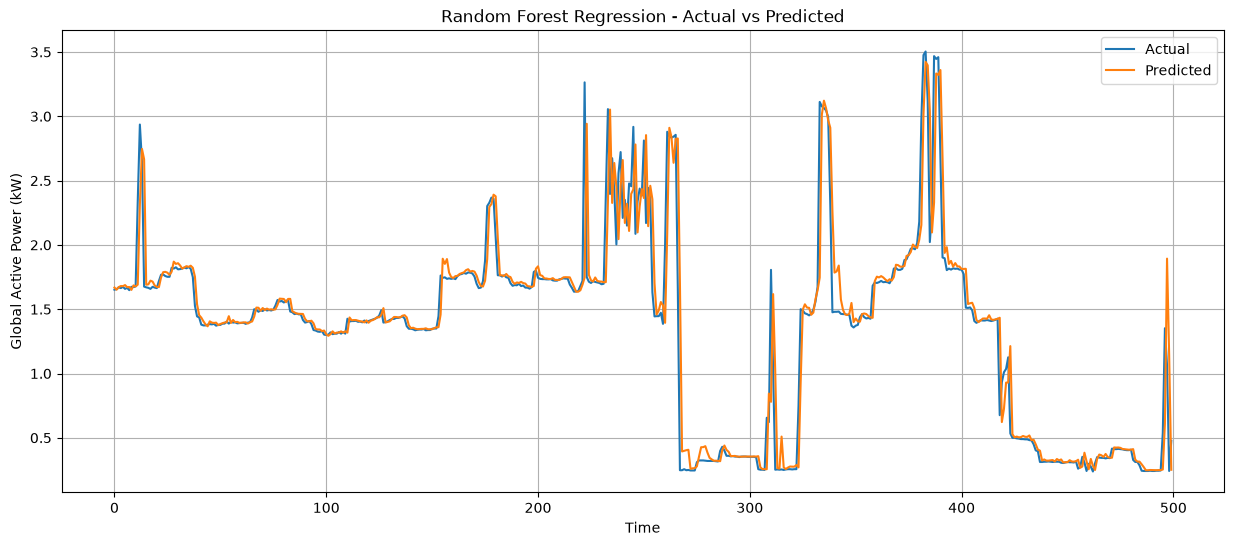

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.iloc[:500].values,
    label='Actual'
)

plt.plot(
    y_pred_rfr[:500],
    label='Predicted'
)

plt.title(
    'Random Forest Regression - Actual vs Predicted'
)

plt.xlabel('Time')

plt.ylabel(
    'Global Active Power (kW)'
)

plt.legend()

plt.grid(True)

plt.show()

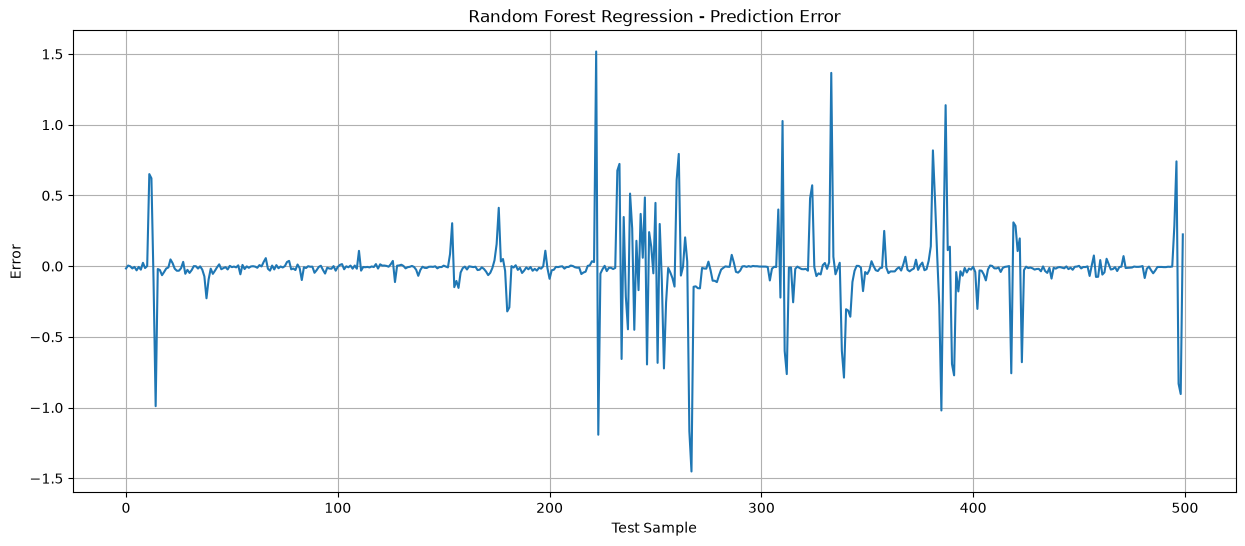

In [20]:
rfr_errors = (
    y_test.values - y_pred_rfr
)

plt.figure(figsize=(15, 6))

plt.plot(
    rfr_errors[:500]
)

plt.title(
    'Random Forest Regression - Prediction Error'
)

plt.xlabel(
    'Test Sample'
)

plt.ylabel(
    'Error'
)

plt.grid(True)

plt.show()

In [21]:
feature_importance = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': rfr_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
0      Power_Lag_1    0.968125
1      Power_Lag_5    0.006757
2     Power_Lag_15    0.005155
3     Power_Lag_60    0.004140
4   Power_Lag_1440    0.003888
9           Minute    0.002803
8             Hour    0.002599
7              Day    0.002358
6            Month    0.001730
10       DayOfWeek    0.001188
5             Year    0.001082
11       IsWeekend    0.000175


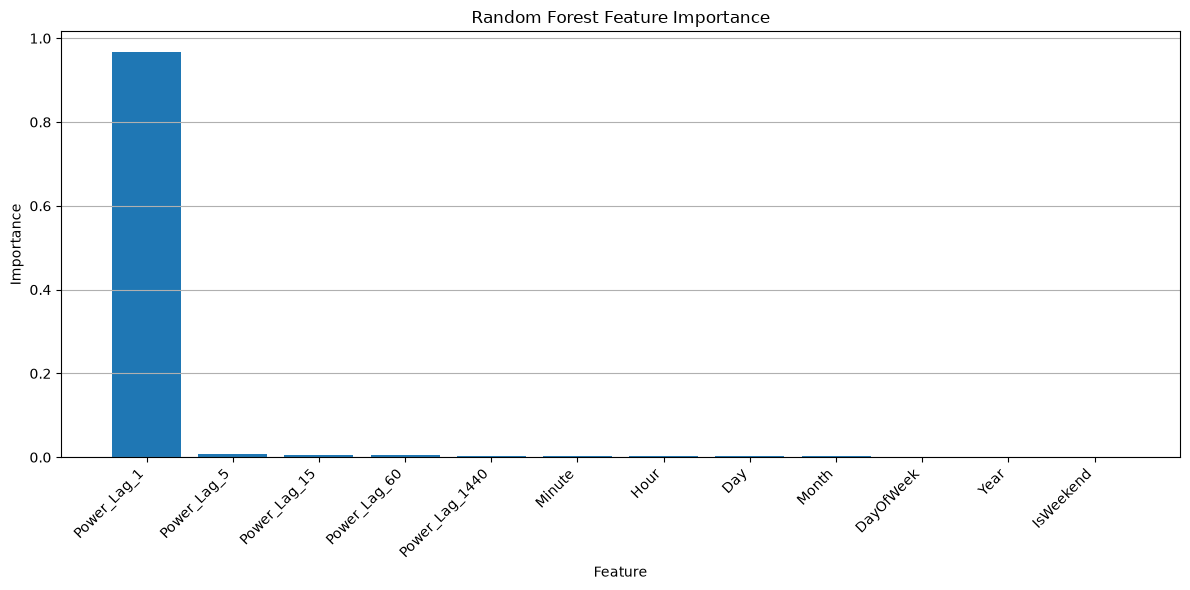

In [22]:
plt.figure(figsize=(12, 6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title(
    'Random Forest Feature Importance'
)

plt.xlabel('Feature')

plt.ylabel('Importance')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(axis='y')

plt.tight_layout()

plt.show()

In [23]:
def predict_power_rfr(
    power_lag_1,
    power_lag_5,
    power_lag_15,
    power_lag_60,
    power_lag_1440,
    year,
    month,
    day,
    hour,
    minute,
    day_of_week
):

    try:

        is_weekend = (
            1 if day_of_week >= 5
            else 0
        )

        input_data = pd.DataFrame({

            'Power_Lag_1': [
                power_lag_1
            ],

            'Power_Lag_5': [
                power_lag_5
            ],

            'Power_Lag_15': [
                power_lag_15
            ],

            'Power_Lag_60': [
                power_lag_60
            ],

            'Power_Lag_1440': [
                power_lag_1440
            ],

            'Year': [
                year
            ],

            'Month': [
                month
            ],

            'Day': [
                day
            ],

            'Hour': [
                hour
            ],

            'Minute': [
                minute
            ],

            'DayOfWeek': [
                day_of_week
            ],

            'IsWeekend': [
                is_weekend
            ]
        })

        prediction = rfr_model.predict(
            input_data
        )[0]

        return f"{prediction:.4f} kW"

    except Exception as e:

        return f"Error: {str(e)}"

In [24]:
with gr.Blocks(
    title="Smart Grid Power Forecasting - Random Forest"
) as demo_rfr:

    gr.Markdown(
        """
        # ⚡ Smart Grid Power Forecasting

        ## Random Forest Regression Model

        Predict **Global Active Power (kW)** using
        historical household power consumption.
        """
    )

    gr.Markdown(
        """
        Enter previous power consumption values
        and the date/time information.
        """
    )

    gr.Markdown(
        "### Previous Power Consumption"
    )

    with gr.Row():

        power_lag_1 = gr.Number(
            label="Power 1 Minute Ago",
            value=1.0
        )

        power_lag_5 = gr.Number(
            label="Power 5 Minutes Ago",
            value=1.0
        )

        power_lag_15 = gr.Number(
            label="Power 15 Minutes Ago",
            value=1.0
        )

    with gr.Row():

        power_lag_60 = gr.Number(
            label="Power 1 Hour Ago",
            value=1.0
        )

        power_lag_1440 = gr.Number(
            label="Power 1 Day Ago",
            value=1.0
        )

    gr.Markdown(
        "### Date & Time"
    )

    with gr.Row():

        year = gr.Number(
            label="Year",
            value=2007
        )

        month = gr.Slider(
            minimum=1,
            maximum=12,
            step=1,
            value=1,
            label="Month"
        )

        day = gr.Slider(
            minimum=1,
            maximum=31,
            step=1,
            value=1,
            label="Day"
        )

    with gr.Row():

        hour = gr.Slider(
            minimum=0,
            maximum=23,
            step=1,
            value=12,
            label="Hour"
        )

        minute = gr.Slider(
            minimum=0,
            maximum=59,
            step=1,
            value=0,
            label="Minute"
        )

        day_of_week = gr.Slider(
            minimum=0,
            maximum=6,
            step=1,
            value=0,
            label="Day of Week (0=Monday, 6=Sunday)"
        )

    predict_button = gr.Button(
        "⚡ Predict Power",
        variant="primary"
    )

    prediction_output = gr.Textbox(
        label="Predicted Global Active Power"
    )

    predict_button.click(
        fn=predict_power_rfr,

        inputs=[
            power_lag_1,
            power_lag_5,
            power_lag_15,
            power_lag_60,
            power_lag_1440,
            year,
            month,
            day,
            hour,
            minute,
            day_of_week
        ],

        outputs=prediction_output
    )


demo_rfr.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
